In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [35]:
df=pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [36]:
df=df.drop(columns=["User ID", "Gender"])

In [37]:
y=df["Purchased"]
X=df.drop(columns=["Purchased"])

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': list(range(1,21))
}

knn=KNeighborsClassifier()

grid= GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

grid.fit(X_train,y_train)
print("Best k:", grid.best_params_['n_neighbors'])
print("Best CV accuracy:", grid.best_score_)


Best k: 16
Best CV accuracy: 0.8964285714285716


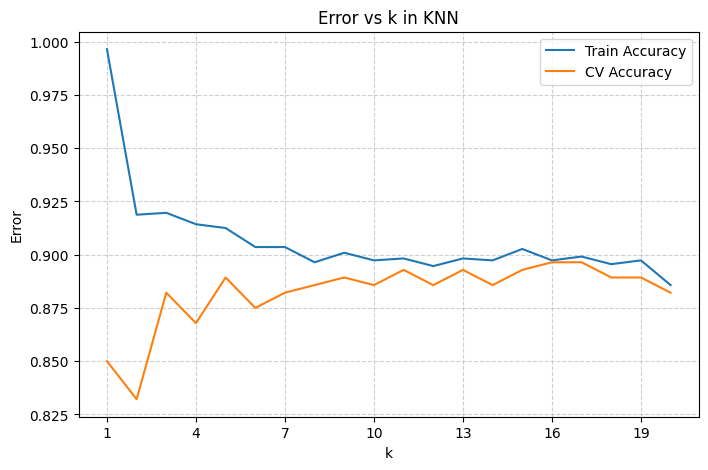

In [50]:
plt.figure(figsize=(8, 5))
results = pd.DataFrame(grid.cv_results_)
k_values = results['param_n_neighbors']
train_scores = results['mean_train_score']
cv_scores = results['mean_test_score']

plt.plot(k_values, train_scores, label='Train Accuracy')
plt.plot(k_values, cv_scores, label='CV Accuracy')

plt.xlabel("k")
plt.ylabel("Error")
plt.title("Error vs k in KNN")
plt.legend()
plt.xticks(range(1, 21, 3)) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [51]:
final_model = grid.best_estimator_
final_model

,n_neighbors,16
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
y_pred = final_model.predict(X_test)

In [54]:
print(accuracy_score(y_test,y_pred))

NameError: name 'accuracy_score' is not defined